In [1]:
import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')
if gpus:
   for gpu in gpus:
       tf.config.experimental.set_memory_growth(gpu, True)

print("GPU Available:", tf.config.list_physical_devices('GPU'))

GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
# ── 1. DEPENDENCIES ──────────────────────────────────────────────────────
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, ModelCheckpoint, EarlyStopping
from sklearn.utils import class_weight

In [3]:
# ── 2. PREPROCESSING FUNCTION ────────────────────────────────────────────
def medical_clahe_preprocess(img):
    if img.max() <= 1.0: img = img * 255.0
    img = img.astype('uint8')
    if len(img.shape) == 3:
        img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    img = clahe.apply(img)
    img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
    return img.astype('float32') / 255.0

In [ ]:
# ── 3. GENERATORS ────────────────────────────────────────────────────────
dataset_path = '/Users/Ahmad/UNI-work/year3/FYP/Project/chest-diseases/datasets/Lung Segmentation Data/Lung Segmentation Data'

train_datagen = ImageDataGenerator(
    preprocessing_function=medical_clahe_preprocess,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='constant',
    cval=0
)

val_test_datagen = ImageDataGenerator(preprocessing_function=medical_clahe_preprocess)

train_gen = train_datagen.flow_from_directory(
    os.path.join(dataset_path, 'Train'),
    target_size=(224, 224),
    batch_size=32,
    class_mode='sparse' # This will produce labels 0, 1, and 2
)

val_gen = val_test_datagen.flow_from_directory(
    os.path.join(dataset_path, 'Val'),
    target_size=(224, 224),
    batch_size=32,
    class_mode='sparse',
    shuffle=False
)

# Verify classes (Should print 3 classes)
num_classes = len(train_gen.class_indices)
print(f"Detected Classes: {train_gen.class_indices} (Count: {num_classes})")

Found 21715 images belonging to 3 classes.
Found 5417 images belonging to 3 classes.
Detected Classes: {'COVID-19': 0, 'Non-COVID': 1, 'Normal': 2} (Count: 3)


In [5]:
# ── 4. CLASS WEIGHTS ─────────────────────────────────────────────────────

weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_gen.classes),
    y=train_gen.classes
)
cw_dict = dict(enumerate(weights))
print(cw_dict)

{0: 0.9451989205188474, 1: 1.0042082870884204, 2: 1.0568452815496179}


In [6]:
# ── 5. MODEL ARCHITECTURE ────────────────────────────────────────────────
base = DenseNet121(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Fine-tuning
for layer in base.layers[:300]:
    layer.trainable = False
for layer in base.layers[300:]:
    layer.trainable = True

x = base.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)

# CRITICAL FIX: The units must match num_classes (3)
predictions = Dense(num_classes, activation='softmax')(x) 

model = Model(inputs=base.input, outputs=predictions)

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

2026-04-01 20:26:20.521189: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4
2026-04-01 20:26:20.521213: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-04-01 20:26:20.521216: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-04-01 20:26:20.521238: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:306] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-04-01 20:26:20.521249: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:272] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [7]:
# ── 6. CALLBACKS & TRAINING ──────────────────────────────────────────────
checkpoint_path = '/Users/Ahmad/UNI-work/year3/FYP/Project/chest-diseases/models/trained/best_chest_diseases.keras'

callbacks = [
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, min_lr=1e-7, verbose=1),
    EarlyStopping(monitor='val_accuracy', patience=6, restore_best_weights=True, verbose=1),
    ModelCheckpoint(checkpoint_path, monitor='val_accuracy', save_best_only=True, mode='max', verbose=1)
]

history = model.fit(
    train_gen,
    steps_per_epoch=len(train_gen),
    validation_data=val_gen,
    validation_steps=len(val_gen),
    epochs=30,
    class_weight=cw_dict,
    callbacks=callbacks
)

Epoch 1/30


2026-04-01 20:26:25.424591: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.
2026-04-01 20:26:25.890248: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] model_pruner failed: INVALID_ARGUMENT: Graph does not contain terminal node Adam/AssignAddVariableOp.


679/679 [==============================] - ETA: 0s - loss: 0.6659 - accuracy: 0.7566
Epoch 1: val_accuracy improved from -inf to 0.84586, saving model to /Users/Ahmad/UNI-work/year3/FYP/Project/chest-diseases/models/trained/best_chest_diseases.keras
679/679 [==============================] - 231s 331ms/step - loss: 0.6659 - accuracy: 0.7566 - val_loss: 0.4275 - val_accuracy: 0.8459 - lr: 1.0000e-04
Epoch 2/30
679/679 [==============================] - ETA: 0s - loss: 0.5077 - accuracy: 0.8179
Epoch 2: val_accuracy improved from 0.84586 to 0.87982, saving model to /Users/Ahmad/UNI-work/year3/FYP/Project/chest-diseases/models/trained/best_chest_diseases.keras
679/679 [==============================] - 273s 402ms/step - loss: 0.5077 - accuracy: 0.8179 - val_loss: 0.3296 - val_accuracy: 0.8798 - lr: 1.0000e-04
Epoch 3/30
679/679 [==============================] - ETA: 0s - loss: 0.4428 - accuracy: 0.8450
Epoch 3: val_accuracy improved from 0.87982 to 0.89441, saving model to /Users/Ahmad/U

In [8]:
# 1. Save the entire model (Architecture + Weights + Optimizer state)
model.save('best_chest-diseases2.keras', '/Users/Ahmad/UNI-work/year3/FYP/Project/chest-diseases/models/trained') 

In [9]:
# ── 8: Evaluation ──────────────────────────────────────────────────────────────────

def plot_model_history (history):
    plt.figure(figsize=(12,4))
    plt.subplot(121)
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title('Model loss by epoch')
    plt.ylabel('loss')
    plt.xlabel('epoch')
    plt.legend(['train', 'val'], loc='right')

    plt.subplot(122)
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title('Model acc by epoch')
    plt.ylabel('acc')
    plt.xlabel('epoch')
    plt.legend(['train', 'val'], loc='right')
    plt.show()

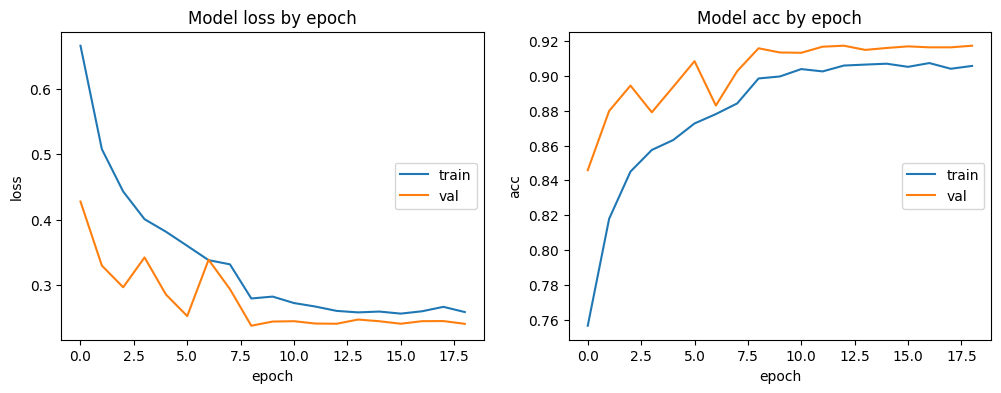

In [10]:
plot_model_history(model.history)

In [11]:
from tensorflow.keras.models import load_model
Model_DNet = load_model('/Users/Ahmad/UNI-work/year3/FYP/Project/chest-diseases/best_chest-diseases2.keras')

In [ ]:
# ── 9. DEFINE THE TEST GENERATOR ─────────────────────────────────────────
# Use the same preprocessing as the training/validation sets
test_datagen = ImageDataGenerator(preprocessing_function=medical_clahe_preprocess)

test_gen = test_datagen.flow_from_directory(
    os.path.join(dataset_path, 'Test'),
    target_size=(224, 224),
    batch_size=32,
    class_mode='sparse',
    shuffle=False # CRITICAL: Keep False for the Confusion Matrix
)

# ── 10. EVALUATE THE MODEL ────────────────────────────────────────────────
print("\nEvaluating on Test Set...")
evaluation = model.evaluate(test_gen)

print(f"\nTest Loss: {evaluation[0]:.4f}")
print(f"Test Accuracy: {evaluation[1]:.2%}")

Found 6788 images belonging to 3 classes.

Evaluating on Test Set...
213/213 [==============================] - 43s 200ms/step - loss: 0.2105 - accuracy: 0.9343

Test Loss: 0.2105
Test Accuracy: 93.43%


213/213 [==============================] - 55s 251ms/step
              precision    recall  f1-score   support

           0       0.97      0.94      0.95      2395
           1       0.95      0.91      0.93      2253
           2       0.88      0.96      0.92      2140

    accuracy                           0.93      6788
   macro avg       0.93      0.93      0.93      6788
weighted avg       0.94      0.93      0.93      6788



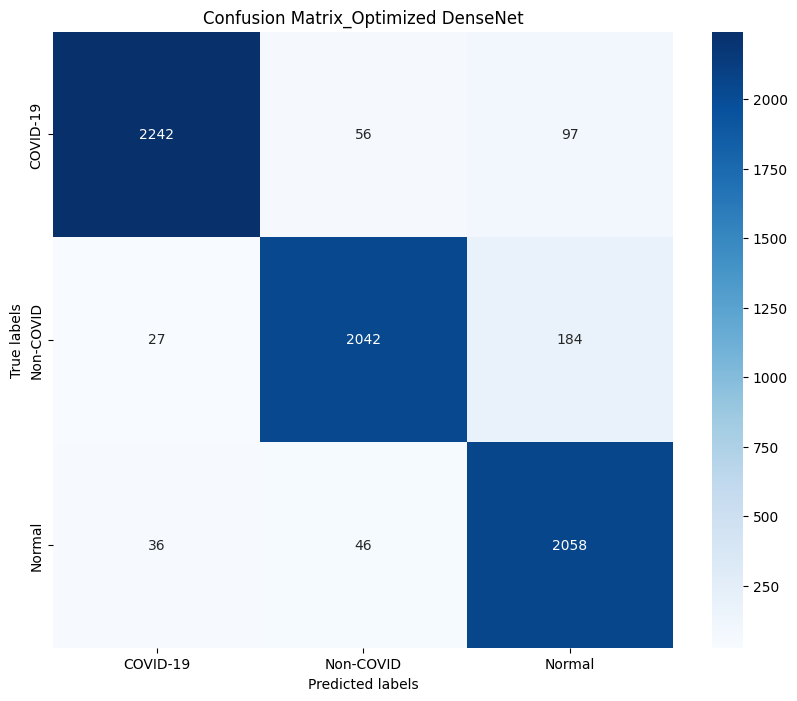

In [14]:
# Confusion_ matrix:

import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Generate predictions on the test data
predictions = model.predict(test_gen)
# Get the predicted classes
predicted_classes = np.argmax(predictions, axis=1)
# Get the true classes
true_classes = test_gen.classes

# Calculate the confusion matrix
conf_matrix = confusion_matrix(true_classes, predicted_classes)
print(classification_report(true_classes, predicted_classes))
# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=test_gen.class_indices.keys(), yticklabels=test_gen.class_indices.keys())
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix_Optimized DenseNet')
plt.show()